#### HITL (Human in the loop) in Agentic Ai 1st e.g

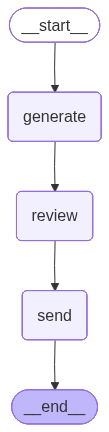

In [ ]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, END
from langgraph.types import interrupt, Command   # main classes that used to interact with human in the loop
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()


class EmailState(TypedDict):
    user_input: str
    draft: Optional[str]
    approved: Optional[bool]   # recieve through command invoke 
    final_email: Optional[str]


def generate_draft(state: EmailState):

    draft = f"Dear Sir,\n{state['user_input']}\nRegards"
    return {"draft": draft}


def human_review(state: EmailState):
    # Pause execution and wait for human input
    human_response = interrupt(
        {
            "draft": state["draft"],
            "message": "Approve or edit this email",
        }
    )


    if human_response.get("approved"):
        final_email = human_response.get("edited_text", state["draft"])
        return {"approved": True, "final_email": final_email if final_email else state['draft']}   # to come out from interrupt situation, pass these value with same key by commands function 
    else:
        return {"approved": False, "final_email": None}


def send_email(state: EmailState):
    if state["approved"]:
        print("Email Sent :\n", state["final_email"])
        return {"final_names":state["final_email"]} 
    else:
        print("❌ Email rejected")
        return state 


builder = StateGraph(EmailState)

builder.add_node("generate", generate_draft)
builder.add_node("review", human_review)
builder.add_node("send", send_email)

builder.set_entry_point("generate")

builder.add_edge("generate", "review")
builder.add_edge("review", "send")
builder.add_edge("send", END)

graph = builder.compile(checkpointer=checkpointer)  # In Memory Saver checkpoint 
graph

# review node has HITL, human approval


##### Paused workflow due to interrupt

In [ ]:
initial_input = {"user_input": "I want to request leave for 2 days"}
config = {"configurable": {"thread_id": "user-123"}}  
result = graph.invoke(initial_input,config=config)

print(f"draft message :\n {result['__interrupt__'][0].value['draft']} \n\n{result['__interrupt__'][0].value['message']} ???")

draft message :
 Dear Sir,
I want to request leave for 2 days
Regards 

Approve or edit this email ???


#### Resume workflow through command

In [61]:
from langgraph.types import Command


# Ask user for approval
approval = input("Approve? (yes/no): ").strip().lower()

if approval == "yes" or approval == "y":
    edited = input("Do you want to edit the email? (leave blank to keep same): ")
    
    human_response = {
        "approved": True,
        "edited_text": edited if edited else None
    }
else:
    human_response = {
        "approved": False
    }



resume_result = graph.invoke(Command(resume=human_response), config=config)

Email Sent :
 Dear Sir,
I want to request leave for 2 days
Regards


In [62]:
resume_result

{'user_input': 'I want to request leave for 2 days',
 'draft': 'Dear Sir,\nI want to request leave for 2 days\nRegards',
 'approved': True,
 'final_email': 'Dear Sir,\nI want to request leave for 2 days\nRegards'}

##### Human edited the email during approval

In [63]:
from langgraph.types import Command


# Ask user for approval
approval = input("Approve? (yes/no): ").strip().lower()

if approval == "yes" or approval == "y":
    edited = input("Do you want to edit the email? (leave blank to keep same): ")
    
    human_response = {
        "approved": True,
        "edited_text": edited if edited else None
    }
else:
    human_response = {
        "approved": False
    }



resume_result = graph.invoke(Command(resume=human_response), config=config)

In [64]:
resume_result

{'user_input': 'I want to request leave for 2 days',
 'draft': 'Dear Sir,\nI want to request leave for 2 days\nRegards',
 'approved': True,
 'final_email': 'Dear Sir,\nI want to request leave for 2 days\nRegards'}

#### Human declined the approval

In [51]:
from langgraph.types import Command


# Ask user for approval
approval = input("Approve? (yes/no): ").strip().lower()

if approval == "yes" or approval == "y":
    edited = input("Do you want to edit the email? (leave blank to keep same): ")
    
    human_response = {
        "approved": True,
        "edited_text": edited if edited else None
    }
else:
    human_response = {
        "approved": False
    }



resume_result = graph.invoke(Command(resume=human_response), config=config)

❌ Email rejected


In [58]:
initial_input = {"user_input": "I want to request leave for 2 days"}
config = {"configurable": {"thread_id": "user-123"}}
result = graph.invoke(initial_input,config=config)

print(f"draft message :\n {result['__interrupt__'][0].value['draft']} \n\n{result['__interrupt__'][0].value['message']} ??? press (yes/no)  : ")



# Ask user for approval
approval = input("Approve? (yes/no): ").strip().lower()
print("Human Approval  :  ",approval,"\n")

if approval == "yes" or approval == "y":
    edited = input("Do you want to edit the email? (leave blank to keep same): ")
    
    human_response = {
        "approved": True,
        "edited_text": edited if edited else None
    }
else:
    human_response = {
        "approved": False
    }



resume_result = graph.invoke(Command(resume=human_response), config=config)

draft message :
 Dear Sir,
I want to request leave for 2 days
Regards 

Approve or edit this email ??? press (yes/no)  : 
Human Approval  :   yes 

📧 email Sent :
 Dear Sir,
I want to request leave for 2 days
Regards


#### Thank you